In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import os
import numpy as np
import seaborn as sns
import pandas as pd

In [42]:
def structural_characterization (G_net):
    #read the file
    # path = "activityA1/" + filename
    # G_net = nx.read_pajek(path)
    # G_net = nx.Graph(G_net)
    # print(f'Structural characterization of '+ filename +' network:')

    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        print("Graph is not connected, using largest connected component")

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

In [40]:
# If your header starts with a specific word or character, use comments
G = nx.read_edgelist(
    "/Volumes/MZ BACKUP/data/beem_static/filtered_iHMP_IBDMDB_2019_network.edgelist", 
    data=[("weight", float)], 
    comments="weight"  # This tells it to ignore any line starting with 'weight'
)
# Check if it worked
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

Nodes: 200
Edges: 412


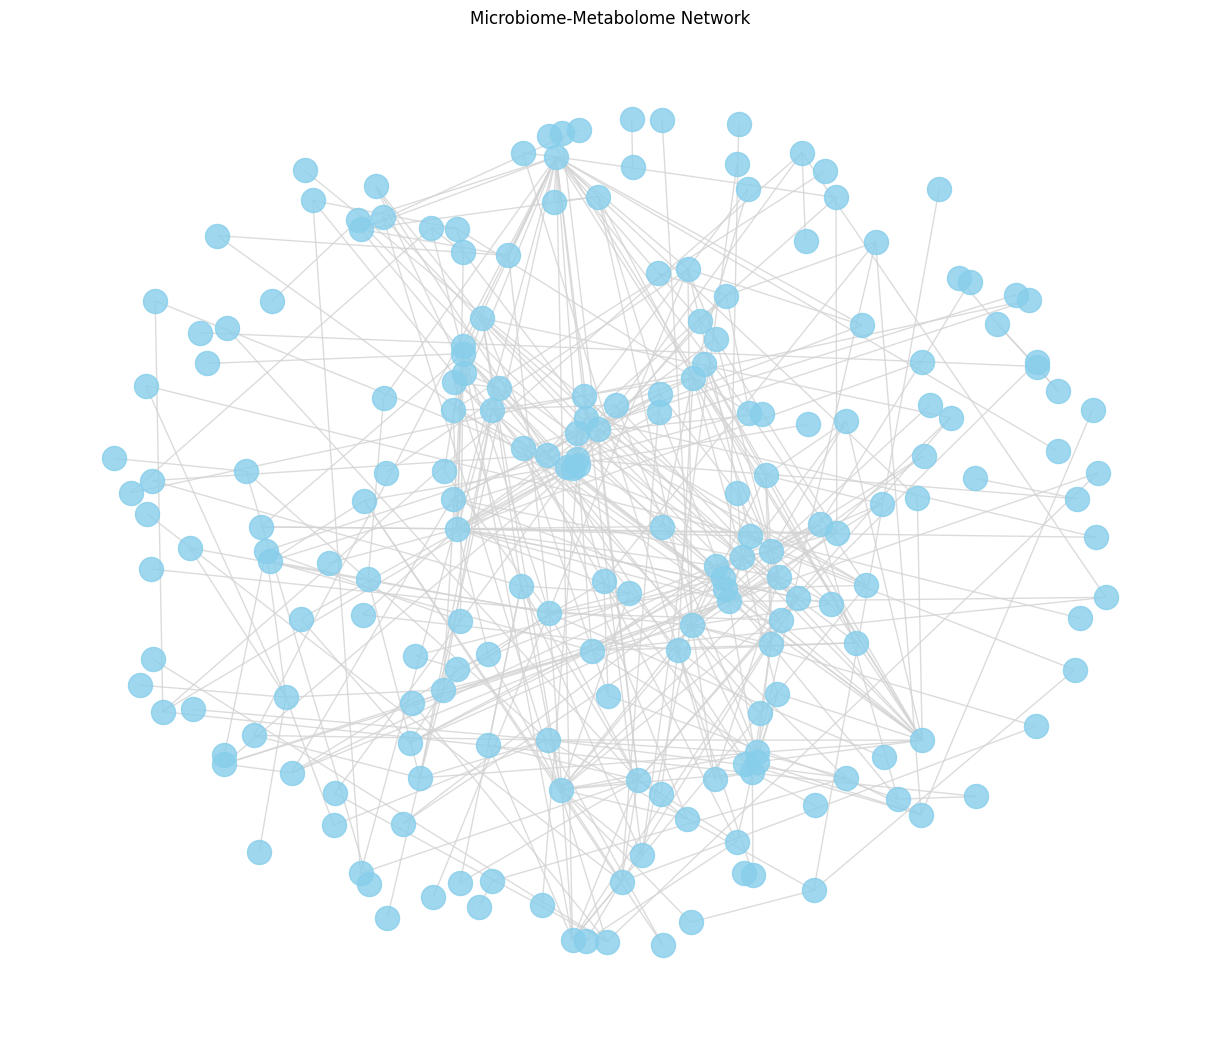

In [41]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G, k=0.15, seed=42) 

# Draw the network
nx.draw(G, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Microbiome-Metabolome Network")
plt.show()

In [43]:
structural_characterization(G)

Number of nodes: 200
Number of edges: 412
Minimum Degree: 1
Maximum Degree: 25
Average Degree: 4.12
Average Clustering Coefficient: 0.1151
Assortativity Coefficient (r): -0.2025
Graph is not connected, using largest connected component
Average Shortest Path Length: 3.87
Diameter: 9
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [44]:
from collections import Counter

def degree_distribution(G):
    fig, ax = plt.subplots(figsize=(5, 3))
    
    degree_sequence = [G.degree(node) for node in G.nodes()]
    num_nodes = len(G.nodes())
    
    degree_counts = Counter(degree_sequence)
    min_degree = min(degree_sequence)
    max_degree = max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_probs = [degree_counts.get(x, 0) / num_nodes for x in degrees]

    ax.scatter(degrees, degree_probs, label='data')

    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.tick_params(which='major', axis='both', labelsize=15)
    ax.set_title('Degree Distribution (Linear Scale)', fontsize=15)
    
    fig.tight_layout()
    plt.show()

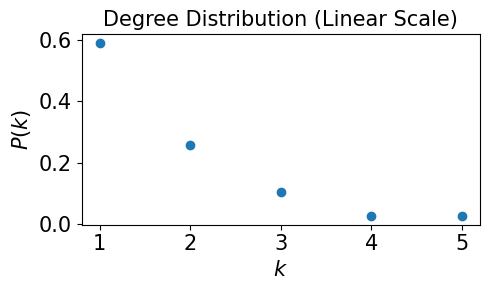

In [25]:
degree_distribution(G)

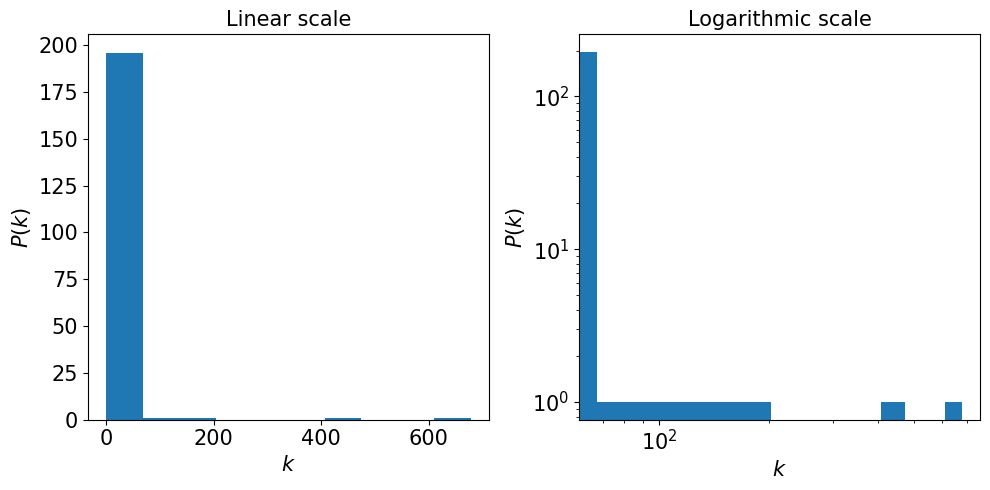

In [45]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G.degree(node, weight='weight') for node in G.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [27]:
def plot_degree_distributions(file_pattern):
    files = sorted(glob.glob(file_pattern))[:100] # Ensure we only take the first 100

    # 2. Initialize the grid (10 rows, 10 columns)
    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    axes = axes.flatten() # Flatten to 1D array for easy iteration
    edge_data_schema = [('weight', float)]
    for i, file_path in enumerate(files):
        # Load the edgelist
        # Note: adjust create_using if your graph is directed
        #print(f"Processing: {file_path}")

        G = nx.read_edgelist(file_path, data=edge_data_schema, comments="weight")
        
        # Get the degree of all nodes
        degrees = [d for n, d in G.degree()]
        
        # Plot on the specific subplot
        ax = axes[i]
        ax.hist(degrees, bins=15, color='skyblue', edgecolor='black')
        
        # Clean up formatting for readability
        file_num = os.path.basename(file_path).split('_')[-1].replace('.edgelist', '')
        ax.set_title(f"Run {file_num}", fontsize=8)
        ax.tick_params(labelsize=6)

    # 3. Final layout adjustments
    plt.tight_layout()
    plt.show()

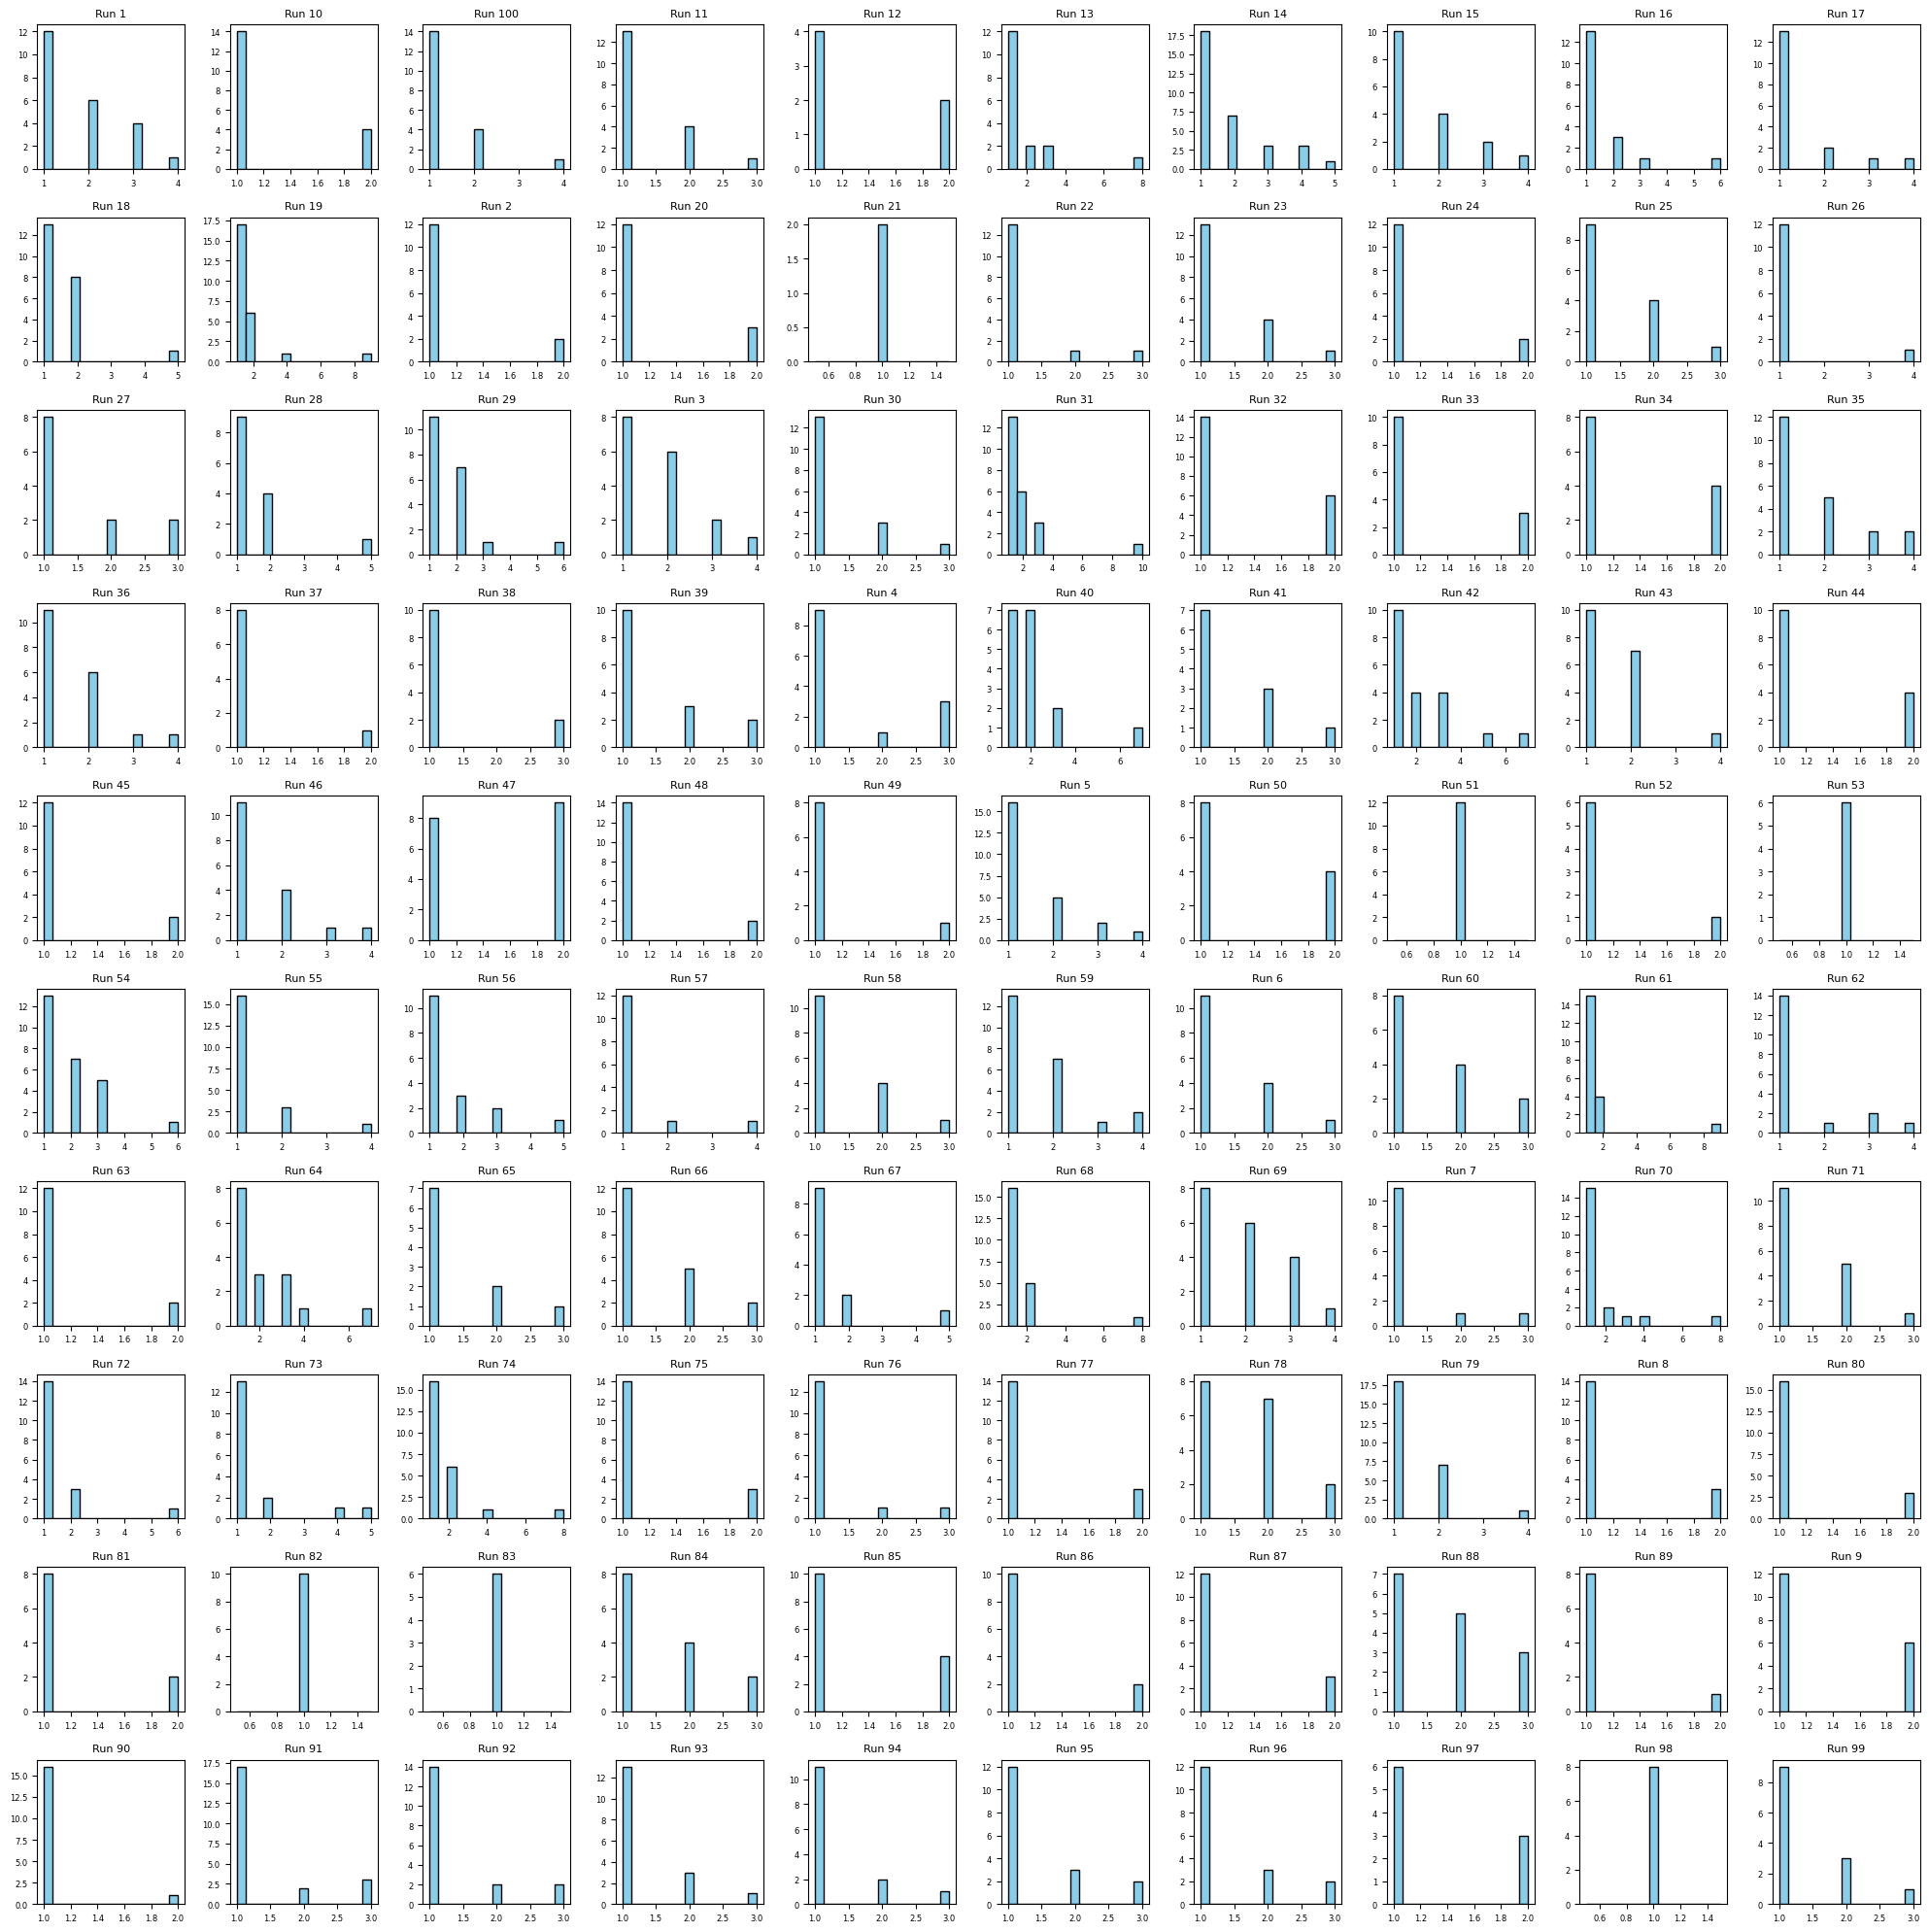

In [28]:
file_pattern_1 = "/Volumes/MZ BACKUP/data/beem_static/iHMP_IBDMDB_2019/random_rows/networks/30/healthy/sample_30_run_network_healthy_*.edgelist"
#file_pattern_2 = "/Volumes/MZ BACKUP/data/networks/iHMP_IBDMDB_2019/random_rows/networks/60/healthy/sample_60_run_network_healthy_*.edgelist"
#file_pattern_3 = "/Volumes/MZ BACKUP/data/networks/iHMP_IBDMDB_2019/random_rows/networks/90/healthy/sample_90_run_network_healthy_*.edgelist"
plot_degree_distributions(file_pattern_1)
#plot_degree_distributions(file_pattern_2)
#plot_degree_distributions(file_pattern_3)

In [38]:
import pandas as pd
import os

percentages = [30]
num_iterations = 100

results = []

for p in percentages:
	print(f"Processing {p}% subsets...")

	for i in range(1, num_iterations + 1):
		filename = f"sample_{p}_run_network_unhealthy_{i}.edgelist"
		path = f"iHMP_IBDMDB_2019/random_rows/networks/{p}/unhealthy/{filename}"

		if not os.path.isfile(path):
			continue

		print(f"Reading: {filename}")

		try:
			# 1. Read the file without the 'comment' trigger
			df = pd.read_csv(path, sep='\t', names=['source', 'target', 'weight'], header=None)

			# 2. Convert 'weight' to numeric, forcing errors to NaN (skips strings like "weight")
			df['weight'] = pd.to_numeric(df['weight'], errors='coerce')

			# 3. Drop any rows that couldn't be converted (like headers or text comments)
			df = df.dropna(subset=['weight'])

			# 4. Proceed with your math
			sum_pos = df.loc[df['weight'] > 0, 'weight'].sum()
			sum_neg = df.loc[df['weight'] < 0, 'weight'].abs().sum()

			# Avoid division by zero if a network is empty
			total_weight = sum_pos + sum_neg
			if total_weight == 0:
				rho_inferred = 0
			else:
				rho_inferred = (sum_pos - sum_neg) / total_weight

			results.append((p, i, rho_inferred))

		except Exception as e:
			print(f"Error reading {filename}: {e}")

all_results = pd.DataFrame(results, columns=["Percentage", "Iteration", "Rho"])
all_results.to_csv('results/df_unhealthy_30_60_90_iHMP_IBDMDB_2019_rows.tsv', sep='\t', index=False)

Processing 30% subsets...
Reading: sample_30_run_network_unhealthy_1.edgelist
Reading: sample_30_run_network_unhealthy_2.edgelist
Reading: sample_30_run_network_unhealthy_3.edgelist
Reading: sample_30_run_network_unhealthy_4.edgelist
Reading: sample_30_run_network_unhealthy_5.edgelist
Reading: sample_30_run_network_unhealthy_6.edgelist
Reading: sample_30_run_network_unhealthy_7.edgelist
Reading: sample_30_run_network_unhealthy_8.edgelist
Reading: sample_30_run_network_unhealthy_9.edgelist
Reading: sample_30_run_network_unhealthy_10.edgelist
Reading: sample_30_run_network_unhealthy_11.edgelist
Reading: sample_30_run_network_unhealthy_12.edgelist
Reading: sample_30_run_network_unhealthy_13.edgelist
Reading: sample_30_run_network_unhealthy_14.edgelist
Reading: sample_30_run_network_unhealthy_15.edgelist
Reading: sample_30_run_network_unhealthy_16.edgelist
Reading: sample_30_run_network_unhealthy_17.edgelist
Reading: sample_30_run_network_unhealthy_18.edgelist
Reading: sample_30_run_networ

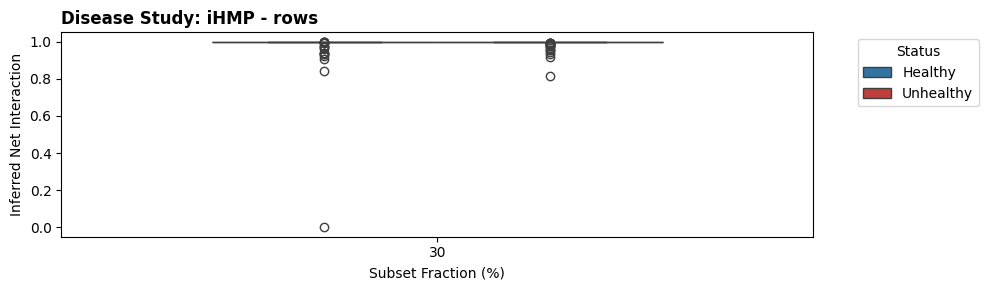

In [39]:
# 1. Load and Preprocess Data
all_data = []

# Update this path to where your files are stored
file_list = glob.glob("results/*.tsv")

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.split('_')
    
    # Extract metadata from filename
    # Example: df_healthy_30_60_90_YACHIDA_CRC_2019_rows.tsv
    status = parts[1]      # healthy / unhealthy
    dimension = parts[-1].replace('.tsv', '') # rows / columns
    disease = parts[5]     # e.g., YACHIDA, iHMP, WANG
    
    df = pd.read_csv(file_path, sep='\t')
    df['Status'] = status.capitalize()
    df['Disease'] = disease
    df['Dimension'] = dimension
    all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)

# 2. Plotting Function
def plot_dimension(df, dim_name):
    subset = df[df['Dimension'] == dim_name]
    diseases = subset['Disease'].unique()
    
    fig, axes = plt.subplots(len(diseases), 1, figsize=(10, 3 * len(diseases)), sharex=True)
    
    # If only one disease, axes isn't a list
    if len(diseases) == 1: axes = [axes]
    
    for i, disease in enumerate(diseases):
        data_plot = subset[subset['Disease'] == disease]
        
        sns.boxplot(
            data=data_plot, 
            x='Percentage', 
            y='Rho', 
            hue='Status',
            ax=axes[i],
            palette={'Healthy': '#1f77b4', 'Unhealthy': '#d62728'},
            width=0.6
        )
        
        axes[i].set_title(f"Disease Study: {disease} - {dim_name}", loc='left', fontweight='bold')
        axes[i].set_ylabel("Inferred Net Interaction")
        axes[i].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.xlabel("Subset Fraction (%)")
    plt.tight_layout()
    plt.savefig(f"plot_{dim_name}.png", dpi=300)
    plt.show()

# 3. Execute
plot_dimension(master_df, 'rows')
#plot_dimension(master_df, 'columns')